In [1]:
import sys
sys.path.append("..")
from src.pose_extractor import extract_keypoints_from_video
from src.geometry import knee_angle, torso_lean, detect_contact_frame

video_path = "../data/raw_clips/header/header_02.mp4"
keypoints = extract_keypoints_from_video(video_path)
knee_angles = [knee_angle(kp) for kp in keypoints]
torso_angles = [torso_lean(kp) for kp in keypoints]
contact = detect_contact_frame(keypoints, shot_type="header")

2026-07-18 23:39:57,389 - INFO - Extracted keypoints for 50 frames from ../data/raw_clips/header/header_02.mp4


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.05)
PALETTE = ["#0f4c3a", "#1a7a5e", "#2fa084", "#5cbfa3", "#8ad4bf", "#b8e6d8"]
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.edgecolor"] = "#cccccc"

dual-axis styled biomechanics chart

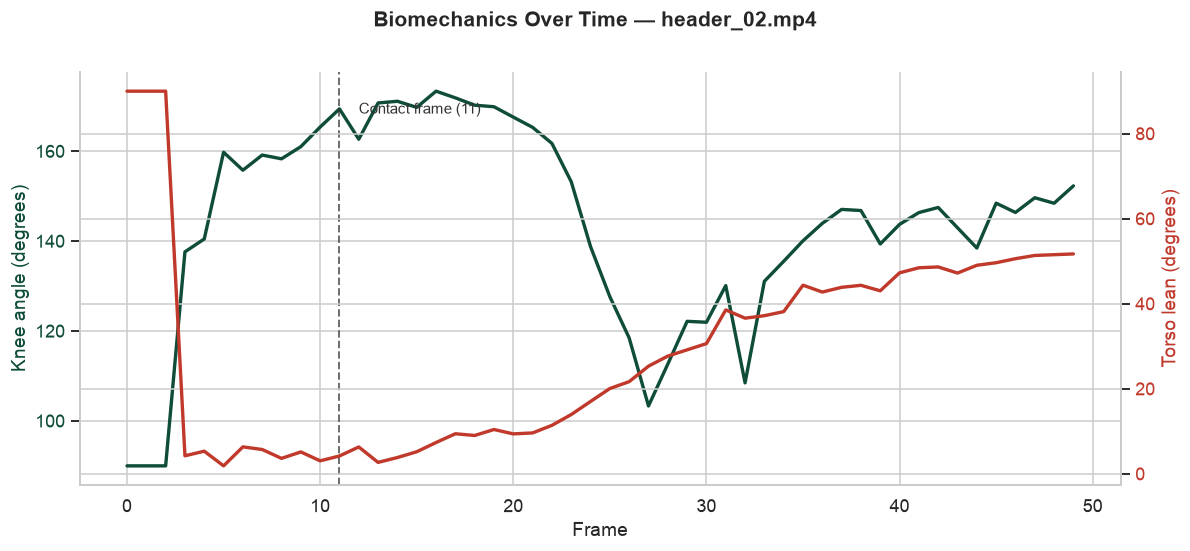

In [3]:
fig, ax1 = plt.subplots(figsize=(11, 5))

ax1.plot(knee_angles, color=PALETTE[0], linewidth=2.2, label="Knee angle (°)")
ax1.set_xlabel("Frame")
ax1.set_ylabel("Knee angle (degrees)", color=PALETTE[0])
ax1.tick_params(axis="y", labelcolor=PALETTE[0])
ax1.spines[["top"]].set_visible(False)

ax2 = ax1.twinx()
ax2.plot(torso_angles, color="#c0392b", linewidth=2.2, linestyle="-", label="Torso lean (°)")
ax2.set_ylabel("Torso lean (degrees)", color="#c0392b")
ax2.tick_params(axis="y", labelcolor="#c0392b")
ax2.spines[["top"]].set_visible(False)

ax1.axvline(contact, color="#333", linestyle="--", linewidth=1.3, alpha=0.7)
ax1.text(contact + 1, max(knee_angles) - 5, f"Contact frame ({contact})", fontsize=9.5, color="#333")

fig.suptitle("Biomechanics Over Time — header_02.mp4", fontsize=14, fontweight="bold", y=1.0)
fig.tight_layout()
plt.show()